# 23 FS3 Decision-Relevant Forecast Evaluation

This notebook is the generator-owned **final DA evaluation layer before the thesis conclusion**.

The goal is not to find the single lowest-error forecaster in a forecasting-paper sense. The goal is to decide whether the current deterministic hourly DA forecast is sufficiently realistic, robust, and implementable for downstream thesis use in scenario generation and stochastic optimisation.

The decision frame is:
- official naive benchmark
- best/current FS2 reference
- final FS3 candidates

The comparison is intentionally wider than MAE:
- transparent classical accuracy with `rMAE` anchored to the official naive benchmark
- horizon robustness across `D` through `D+4`
- daily price-level retention
- intraday shape retention
- expensive/cheap-hour identification
- tail and high-volatility behaviour
- frozen objective week behaviour
- runtime, implementability, and thesis explainability

No hidden composite score is used.


In [1]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys
import time

import pandas as pd
from IPython.display import Markdown, display

NOTEBOOK_CWD = Path.cwd()
REPO_ROOT = next(
    path for path in [NOTEBOOK_CWD, *NOTEBOOK_CWD.parents] if (path / "scripts/Data/02_Forecasting/01_DA_prices").exists()
)
os.chdir(REPO_ROOT)
PACKAGE_ROOT = REPO_ROOT / "scripts/Data/02_Forecasting/01_DA_prices"
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.append(str(PACKAGE_ROOT))

from hourly_da.core.config import HourlyDAPipelineConfig
from hourly_da.core.external_features import build_external_family_catalog, load_external_feature_store
from hourly_da.core.methodology import (
    STARTER_ENDOGENOUS_FEATURE_NOTE,
    feature_stage_policy_frame,
    model_status_frame,
    shortlisting_policy_frame,
)
from hourly_da.core.reporting import find_latest_run, load_csv, load_json
from hourly_da.core.tuning import build_tuning_placeholder, tuning_cadence_frame, tuning_snippet_frame
from hourly_da.models import naive_model_names
from hourly_da.notebook_support import estimate_run_duration_seconds, format_duration, load_selected_case_weeks

config = HourlyDAPipelineConfig(
    input_csv=REPO_ROOT / "data/01_cleaned/Day_ahead_prices/DA_prices/hourly/da_prices_all_regions_hourly.csv",
    raw_root=REPO_ROOT / "data/00_Raw/DA_Prices",
    cleaned_feature_root=REPO_ROOT / "data/01_cleaned",
    output_root=REPO_ROOT / "data/02_Forecasting/01_DA_prices/hourly_da",
)
output_root = config.output_root


def latest_run_or_none(run_label: str) -> Path | None:
    try:
        return find_latest_run(output_root, run_label)
    except FileNotFoundError:
        return None


def ensure_required_modules(module_names: list[str], install_command: str | None = None) -> None:
    missing = [module_name for module_name in module_names if importlib.util.find_spec(module_name) is None]
    if not missing:
        return

    message_lines = [
        "Missing required package(s) in the active notebook interpreter: " + ", ".join(missing),
        f"Active interpreter: {sys.executable}",
    ]
    if install_command:
        message_lines.append(f"Install command: {install_command}")
    raise RuntimeError("\n".join(message_lines))


def run_command_with_live_output(command: list[str]) -> None:
    print("Running command:")
    print(" ".join(str(part) for part in command))
    process = subprocess.Popen(
        command,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        encoding="utf-8",
        errors="replace",
        bufsize=1,
    )

    output_tail: list[str] = []
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
        output_tail.append(line)
        if len(output_tail) > 40:
            output_tail.pop(0)

    return_code = process.wait()
    if return_code != 0:
        tail_text = "".join(output_tail).strip()
        message = f"Command failed with exit code {return_code}."
        if tail_text:
            message += "\nLast output:\n" + tail_text
        raise RuntimeError(message)


In [2]:
from IPython.display import Image

import matplotlib.pyplot as plt
from matplotlib import dates as mdates

from hourly_da.core.forecast_evaluation import (
    APPENDIX_WEEK_CATEGORIES,
    THESIS_CORE_WEEK_CATEGORIES,
    build_candidate_style_map,
    build_model_selection_summary,
    build_recommendation_inputs,
    build_stitched_d_only_predictions,
    build_week_metric_summary,
    compute_classical_metrics,
    compute_daily_level_metrics,
    compute_daily_shape_metrics,
    compute_diebold_mariano_table,
    compute_horizon_metrics,
    compute_tail_metrics,
    compute_topk_hour_metrics,
    default_decision_thresholds,
    discover_final_candidate_runs,
    load_candidate_model_settings,
    load_candidate_predictions,
    load_candidate_runtime_summary,
    load_frozen_selected_weeks,
    load_official_naive_denominators,
    recommend_candidate,
    run_metric_smoke_checks,
    summarize_candidate_coverage,
    summarize_duplicate_origin_targets,
    summarize_local_day_lengths,
    summarize_missingness,
    summarize_stitched_overlap_check,
)


## Purpose and stopping guidance

Validation remains the structural decision surface. Test is a holdout confirmation layer, not a second tuning loop.

The configurable guidance below is deliberately visible:
- `validation_rMAE < 1.00` is the minimum practical threshold
- `validation_rMAE < 0.95` is preferred
- most major horizons should remain below `rMAE = 1.00`
- large systematic daily level bias is a warning
- shape retention and top-k recall are judged comparatively
- tail failures and objective week failures are reported explicitly
- if FS3 only improves marginally over FS2, the simpler FS2 reference may remain the thesis candidate

Optional `top-6` recall is omitted here to keep the notebook focused on the core `top-3` decision signal.


In [3]:
DECISION_THRESHOLDS = default_decision_thresholds()
display(
    pd.DataFrame(
        [{"threshold": key, "value": value} for key, value in DECISION_THRESHOLDS.items()]
    )
)


,threshold,value
0,validation_rmae_minimum,1.00
1,validation_rmae_preferred,0.95
2,major_horizon_rmae_maximum,1.00
3,large_daily_level_bias_eur_per_mwh,5.00
4,marginal_fs3_rmae_gain_vs_fs2,0.01
5,clear_test_failure_rmae,1.02
6,clear_test_failure_horizon_pass_share,0.40


In [4]:
comparison_discovery = discover_final_candidate_runs(output_root)
candidate_frame = comparison_discovery["candidates"].copy()
availability_table = comparison_discovery["availability"].copy()
fs2_selection_table = comparison_discovery["fs2_selection_table"].copy()
fs2_selection_rule = str(comparison_discovery["fs2_selection_rule"])
official_naive_reference = comparison_discovery["official_naive_reference"]
official_naive_model = str(comparison_discovery["official_naive_model"])
naive_prediction_available = bool(comparison_discovery["naive_prediction_available"])
candidate_order = candidate_frame["candidate_key"].astype(str).tolist()
candidate_label_order = candidate_frame["candidate_label"].astype(str).tolist()
candidate_label_map = candidate_frame.set_index("candidate_key")["candidate_label"].to_dict()
candidate_style_map = build_candidate_style_map(candidate_frame)
report_output_dir = output_root / "notebook_artifacts" / "23_fs3_decision_relevant_forecast_evaluation"
report_output_dir.mkdir(parents=True, exist_ok=True)

timing_rows = []

def _timed(step_name, fn):
    started = time.perf_counter()
    result = fn()
    timing_rows.append({"step": step_name, "seconds": time.perf_counter() - started})
    return result

candidate_predictions = _timed(
    "load_candidate_predictions",
    lambda: load_candidate_predictions(candidate_frame=candidate_frame, config=config),
)
candidate_runtime = _timed(
    "load_candidate_runtime_summary",
    lambda: load_candidate_runtime_summary(candidate_frame),
)
candidate_settings = _timed(
    "load_candidate_model_settings",
    lambda: load_candidate_model_settings(candidate_frame),
)
naive_denominators = _timed(
    "load_official_naive_denominators",
    lambda: load_official_naive_denominators(
        run_dir=comparison_discovery["rmae_reference_run_dir"],
        official_naive_model=official_naive_model,
    ),
)
classical_metrics = _timed(
    "compute_classical_metrics",
    lambda: compute_classical_metrics(candidate_predictions, naive_denominators),
)
horizon_metrics = _timed(
    "compute_horizon_metrics",
    lambda: compute_horizon_metrics(candidate_predictions, naive_denominators),
)
daily_level_metrics, daily_level_summary = _timed(
    "compute_daily_level_metrics",
    lambda: compute_daily_level_metrics(candidate_predictions),
)
daily_shape_metrics, daily_shape_summary = _timed(
    "compute_daily_shape_metrics",
    lambda: compute_daily_shape_metrics(candidate_predictions),
)
topk_daily_metrics, topk_summary = _timed(
    "compute_topk_hour_metrics_top3_only",
    lambda: compute_topk_hour_metrics(candidate_predictions, ks=(3,)),
)
tail_metrics = _timed(
    "compute_tail_metrics",
    lambda: compute_tail_metrics(candidate_predictions),
)
coverage_table = summarize_candidate_coverage(candidate_predictions)
missingness_table = summarize_missingness(candidate_predictions)
duplicate_table = summarize_duplicate_origin_targets(candidate_predictions)
local_day_length_table = summarize_local_day_lengths(candidate_predictions)
smoke_checks = run_metric_smoke_checks(config)
stitched_test_predictions = build_stitched_d_only_predictions(candidate_predictions, split_name="test")
stitched_overlap_check = summarize_stitched_overlap_check(stitched_test_predictions)
selected_weeks_run, selected_core_weeks = load_frozen_selected_weeks(
    output_root,
    categories=THESIS_CORE_WEEK_CATEGORIES,
)
_, selected_appendix_weeks = load_frozen_selected_weeks(
    output_root,
    categories=APPENDIX_WEEK_CATEGORIES,
)
week_metric_summary = _timed(
    "build_week_metric_summary",
    lambda: build_week_metric_summary(
        stitched_test_predictions,
        selected_core_weeks,
        benchmark_candidate_key="official_naive_benchmark" if naive_prediction_available else None,
    ),
)
dm_vs_naive = _timed(
    "compute_dm_vs_naive",
    lambda: compute_diebold_mariano_table(
        candidate_predictions,
        benchmark_candidate_key="official_naive_benchmark",
        challenger_candidate_keys=[key for key in candidate_order if key != "official_naive_benchmark"],
    ) if naive_prediction_available else pd.DataFrame(),
)
dm_vs_fs2 = _timed(
    "compute_dm_vs_best_fs2",
    lambda: compute_diebold_mariano_table(
        candidate_predictions,
        benchmark_candidate_key="best_fs2_reference",
        challenger_candidate_keys=[
            key for key in candidate_order if key.startswith("lear_fs3") or key.startswith("xgboost_fs3")
        ],
    ) if "best_fs2_reference" in set(candidate_frame["candidate_key"].astype(str).tolist()) else pd.DataFrame(),
)
selection_inputs = build_recommendation_inputs(
    classical_metrics,
    horizon_metrics,
    daily_level_summary,
    daily_shape_summary,
    topk_summary,
    tail_metrics,
    candidate_runtime,
)
recommendation = recommend_candidate(selection_inputs, thresholds=DECISION_THRESHOLDS)
selection_summary = build_model_selection_summary(selection_inputs, recommendation)
timing_summary = pd.DataFrame(timing_rows).sort_values("seconds", ascending=False).reset_index(drop=True)
week_plot_candidate_keys = [
    candidate_key
    for candidate_key in candidate_order
    if naive_prediction_available or candidate_key != "official_naive_benchmark"
]

print(f"Frozen case-week selection artifact: {selected_weeks_run.name}")
print(f"Evaluation output folder: {report_output_dir}")
print(f"Prediction rows loaded: {candidate_predictions.shape[0]:,}")
print(f"Candidates in scope: {candidate_label_order}")


Frozen case-week selection artifact: 20260404_125748_case_week_selection
Evaluation output folder: C:\Users\marijnvalk\PycharmProjects\Thesis\data\02_Forecasting\01_DA_prices\hourly_da\notebook_artifacts\23_fs3_decision_relevant_forecast_evaluation
Prediction rows loaded: 520,560
Candidates in scope: ['Naive previous week', 'Best FS2 reference', 'LEAR FS3 promoted', 'XGBoost FS3 promoted', 'LEAR FS3 pruned candidate', 'XGBoost FS3 pruned candidate']


## Run discovery and availability


In [5]:
display(availability_table)
display(pd.DataFrame([official_naive_reference]))

if fs2_selection_table.empty:
    print(fs2_selection_rule)
else:
    print(fs2_selection_rule)
    display(
        fs2_selection_table[
            [
                "candidate_label",
                "model",
                "rmae_vs_official_naive",
                "mae",
                "rmse",
                "bias",
            ]
        ]
        .rename(
            columns={
                "candidate_label": "FS2 candidate",
                "model": "Internal model",
                "rmae_vs_official_naive": "Validation rMAE",
                "mae": "Validation MAE",
                "rmse": "Validation RMSE",
                "bias": "Validation bias",
            }
        )
        .reset_index(drop=True)
    )

display(
    candidate_frame[
        [
            "candidate_label",
            "candidate_context",
            "selected_run_id",
            "selected_model",
            "note",
        ]
    ]
    .rename(
        columns={
            "candidate_label": "Candidate label",
            "candidate_context": "Context",
            "selected_run_id": "Selected run",
            "selected_model": "Internal model",
            "note": "Selection note",
        }
    )
)


,candidate_label,run_label,latest_folder,selected_complete_folder,selected_model,status,prediction_artifact,missing_latest_artifacts,note
0,LEAR FS2,lear_fs2_benchmark,20260409_102003_lear_fs2_benchmark,20260409_102003_lear_fs2_benchmark,lear_fs2,complete,predictions_long.parquet,,Latest complete run selected.
1,XGBoost FS2,xgboost_fs2_benchmark,20260409_103625_xgboost_fs2_benchmark,20260409_103625_xgboost_fs2_benchmark,xgboost_fs2,complete,predictions_long.parquet,,Latest complete run selected.
2,LEAR FS3 promoted,lear_fs3_combo_promoted_benchmark,20260425_124242_lear_fs3_combo_promoted_benchmark,20260425_124242_lear_fs3_combo_promoted_benchmark,lear_fs3_combo_promoted,complete,predictions_long.parquet,,Latest complete run selected.
3,XGBoost FS3 promoted,xgboost_fs3_combo_promoted_benchmark,20260424_113834_xgboost_fs3_combo_promoted_ben...,20260424_113834_xgboost_fs3_combo_promoted_ben...,xgboost_fs3_combo_promoted,complete,predictions_long.parquet,,Latest complete run selected.
4,LEAR FS3 pruned candidate,lear_fs3_combo_pruned_candidate_benchmark,20260426_151547_lear_fs3_combo_pruned_candidat...,20260426_151547_lear_fs3_combo_pruned_candidat...,lear_fs3_combo_promoted,complete,predictions_long.parquet,,Latest complete run selected.
5,XGBoost FS3 pruned candidate,xgboost_fs3_combo_pruned_candidate_benchmark,20260426_153605_xgboost_fs3_combo_pruned_candi...,20260426_153605_xgboost_fs3_combo_pruned_candi...,xgboost_fs3_combo_promoted,complete,predictions_long.parquet,,Latest complete run selected.
6,Official naive benchmark,xgboost_fs2_benchmark,20260409_103625_xgboost_fs2_benchmark,20260409_103625_xgboost_fs2_benchmark,naive_previous_week,prediction_ready,predictions_long.parquet,,Prediction rows are loaded from 20260409_10362...
7,Frozen case weeks,case_week_selection,20260404_125748_case_week_selection,20260404_125748_case_week_selection,-,complete,-,,Frozen objective weeks are reused; this notebo...


,model,model_family,fs_level,dataset_split,observations_total,observations_scored,coverage_pct,mae,rmse,bias,...,reporting_level_sort_order,reporting_lead_days,reporting_lead_day_start,reporting_lead_day_end,reporting_lead_day_count,selection_policy,selection_split,selection_reporting_level,selection_metric,minimum_coverage_pct
0,naive_previous_week,naive,FS0,validation,43440,42909,98.777624,27.857794,38.182575,0.523647,...,2,"0,1,2,3,4",0,4,5,minimum_coverage_then_mae,validation,stitched_all_horizon,mae,95.0


Selected from 20260418_151115_model_comparison using validation full-horizon rMAE, then MAE, RMSE, and |bias| as tie-breakers.


,FS2 candidate,Internal model,Validation rMAE,Validation MAE,Validation RMSE,Validation bias
0,XGBoost FS2,xgboost_fs2,0.893665,24.895539,34.775868,5.219137
1,LEAR FS2,lear_fs2,0.979045,27.274043,37.273876,-0.032505


,Candidate label,Context,Selected run,Internal model,Selection note
0,Naive previous week,benchmark,20260409_103625_xgboost_fs2_benchmark,naive_previous_week,Prediction rows are loaded from 20260409_10362...
1,Best FS2 reference,fs2_reference,20260409_103625_xgboost_fs2_benchmark,xgboost_fs2,Latest complete run selected.
2,LEAR FS3 promoted,fs3_promoted,20260425_124242_lear_fs3_combo_promoted_benchmark,lear_fs3_combo_promoted,Latest complete run selected.
3,XGBoost FS3 promoted,fs3_promoted,20260424_113834_xgboost_fs3_combo_promoted_ben...,xgboost_fs3_combo_promoted,Latest complete run selected.
4,LEAR FS3 pruned candidate,fs3_pruned_candidate,20260426_151547_lear_fs3_combo_pruned_candidat...,lear_fs3_combo_promoted,Latest complete run selected.
5,XGBoost FS3 pruned candidate,fs3_pruned_candidate,20260426_153605_xgboost_fs3_combo_pruned_candi...,xgboost_fs3_combo_promoted,Latest complete run selected.


## Data alignment checks


In [6]:
display(smoke_checks)
display(coverage_table)
display(missingness_table)
display(duplicate_table)
display(local_day_length_table)
display(stitched_overlap_check)


,check,passed,details
0,candidate_labels_unique,True,Two synthetic candidates are present and label...
1,day_length_23_present,True,Spring DST day is preserved.
2,day_length_25_present,True,Autumn DST day is preserved.
3,topk_handles_short_days,True,Top-k summary returns a table for 23/24/25-hou...
4,flat_day_correlation_nan,True,At least one flat actual day is counted instea...
5,stitched_targets_unique,True,Stitched D-only forecasts contain no overlappi...


,candidate_label,dataset_split,lead_day,lead_day_label,rows,forecast_origins,unique_targets
0,Best FS2 reference,test,0,D,8664,361,8664
1,Best FS2 reference,test,1,D+1,8664,361,8664
2,Best FS2 reference,test,2,D+2,8664,361,8664
3,Best FS2 reference,test,3,D+3,8664,361,8664
4,Best FS2 reference,test,4,D+4,8664,361,8664
5,Best FS2 reference,validation,0,D,8688,362,8688
6,Best FS2 reference,validation,1,D+1,8688,362,8688
7,Best FS2 reference,validation,2,D+2,8688,362,8688
8,Best FS2 reference,validation,3,D+3,8688,362,8688
9,Best FS2 reference,validation,4,D+4,8688,362,8688


,candidate_label,dataset_split,rows,missing_actuals,missing_predictions,missing_either
0,Best FS2 reference,test,43320,308,0,308
1,Best FS2 reference,validation,43440,261,0,261
2,LEAR FS3 promoted,test,43320,308,92,397
3,LEAR FS3 promoted,validation,43440,261,28,289
4,LEAR FS3 pruned candidate,test,43320,308,92,397
5,LEAR FS3 pruned candidate,validation,43440,261,28,289
6,Naive previous week,test,43320,308,299,607
7,Naive previous week,validation,43440,261,270,531
8,XGBoost FS3 promoted,test,43320,308,92,397
9,XGBoost FS3 promoted,validation,43440,261,28,289


,candidate_label,dataset_split,duplicate_origin_target_rows
0,Best FS2 reference,test,0
1,Best FS2 reference,validation,0
2,LEAR FS3 promoted,test,0
3,LEAR FS3 promoted,validation,0
4,LEAR FS3 pruned candidate,test,0
5,LEAR FS3 pruned candidate,validation,0
6,Naive previous week,test,0
7,Naive previous week,validation,0
8,XGBoost FS3 promoted,test,0
9,XGBoost FS3 promoted,validation,0


,dataset_split,hours_in_local_day,days
0,test,23,1
1,test,24,363
2,test,25,1
3,validation,23,1
4,validation,24,364
5,validation,25,1


,candidate_label,dataset_split,overlap_rows
0,Best FS2 reference,test,0
1,LEAR FS3 promoted,test,0
2,LEAR FS3 pruned candidate,test,0
3,Naive previous week,test,0
4,XGBoost FS3 promoted,test,0
5,XGBoost FS3 pruned candidate,test,0


## Classical accuracy comparison

`rMAE` versus the official naive benchmark is the main classical ranking metric. `MAE` remains visible because it is easy to interpret in `EUR/MWh`, while `RMSE`, `p90`, and `p95` absolute error keep spike sensitivity visible.


,candidate_label,dataset_split,mae,rmse,bias,rmae,smape_pct,median_ae,p90_ae,p95_ae,coverage_pct
0,XGBoost FS3 promoted,test,28.486782,46.693518,5.196457,0.859840,43.824750,17.159353,66.334498,89.336662,99.083564
1,XGBoost FS3 pruned candidate,test,29.350628,47.248046,2.381681,0.885914,45.835733,18.736385,66.187805,85.811599,99.168975
2,Best FS2 reference,test,29.572693,48.558498,4.923680,0.892617,44.361286,17.595709,70.446306,93.331576,99.289012
3,Naive previous week,test,33.130339,54.526402,-0.630994,1.000000,53.793766,19.660000,78.108000,96.110000,98.598800
4,LEAR FS3 pruned candidate,test,34.363389,50.963646,4.821123,1.037218,50.205218,23.963461,75.846221,98.992951,99.083564
5,LEAR FS3 promoted,test,36.876443,61.235767,-1.419053,1.113072,52.876992,23.817499,79.350038,106.852031,99.083564
6,XGBoost FS3 pruned candidate,validation,23.784511,32.164955,-0.854662,0.853783,46.639064,17.550208,53.611487,67.202564,99.355433
7,Best FS2 reference,validation,24.895539,34.775868,5.219137,0.893665,45.948326,17.173677,58.704219,73.733690,99.399171
8,XGBoost FS3 promoted,validation,25.196154,34.793562,5.959745,0.904456,46.550458,17.415497,60.255711,75.855762,99.334715
9,Naive previous week,validation,27.857794,38.182575,0.523647,1.000000,56.278319,19.730000,66.150000,80.288000,98.777624


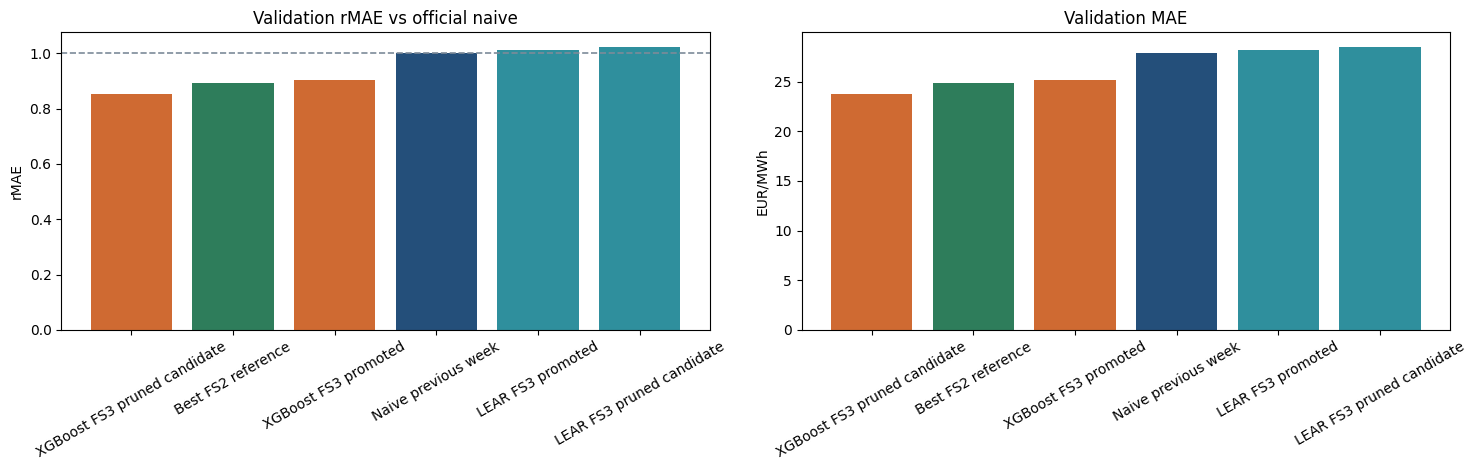

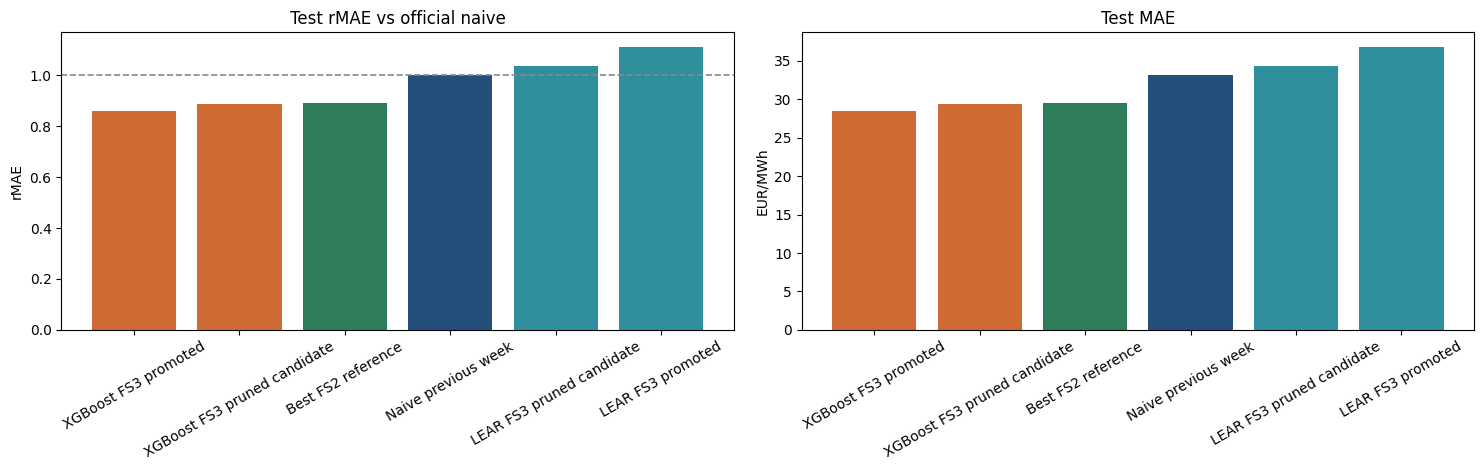

### Diebold-Mariano checks vs official naive

,Split,Reporting view,Challenger,Observations,DM statistic,p-value
0,test,d_only,Best FS2 reference,8545,-6.005292,1.909884e-09
1,test,d_only,LEAR FS3 promoted,8456,-8.233694,2.220446e-16
2,test,d_only,LEAR FS3 pruned candidate,8456,-9.085463,0.000000e+00
3,test,d_only,XGBoost FS3 promoted,8456,-8.619134,0.000000e+00
4,test,d_only,XGBoost FS3 pruned candidate,8493,-9.871962,0.000000e+00
5,test,stitched_all_horizon,Best FS2 reference,42713,-6.732370,1.669220e-11
6,test,stitched_all_horizon,LEAR FS3 promoted,42624,3.835438,1.253406e-04
7,test,stitched_all_horizon,LEAR FS3 pruned candidate,42624,1.946243,5.162562e-02
8,test,stitched_all_horizon,XGBoost FS3 promoted,42624,-10.052677,0.000000e+00
9,test,stitched_all_horizon,XGBoost FS3 pruned candidate,42661,-7.151184,8.604228e-13


### Diebold-Mariano checks vs best FS2 reference

,Split,Reporting view,FS3 challenger,Observations,DM statistic,p-value
0,test,d_only,LEAR FS3 promoted,8514,-4.134938,3.550502e-05
1,test,d_only,LEAR FS3 pruned candidate,8514,-5.427023,5.730183e-08
2,test,d_only,XGBoost FS3 promoted,8514,-6.389926,1.659659e-10
3,test,d_only,XGBoost FS3 pruned candidate,8551,-8.982285,0.000000e+00
4,test,stitched_all_horizon,LEAR FS3 promoted,42923,8.048162,8.881784e-16
5,test,stitched_all_horizon,LEAR FS3 pruned candidate,42923,9.211781,0.000000e+00
6,test,stitched_all_horizon,XGBoost FS3 promoted,42923,-3.580354,3.431294e-04
7,test,stitched_all_horizon,XGBoost FS3 pruned candidate,42960,-0.609329,5.423064e-01
8,validation,d_only,LEAR FS3 promoted,8607,-6.342582,2.259455e-10
9,validation,d_only,LEAR FS3 pruned candidate,8607,-7.331638,2.273737e-13


In [7]:
classical_display = (
    classical_metrics[
        [
            "candidate_label",
            "dataset_split",
            "mae",
            "rmse",
            "bias",
            "rmae",
            "smape_pct",
            "median_ae",
            "p90_ae",
            "p95_ae",
            "coverage_pct",
        ]
    ]
    .sort_values(["dataset_split", "rmae", "mae", "candidate_label"])
    .reset_index(drop=True)
)
display(classical_display)

for split_name in ("validation", "test"):
    part = classical_metrics[classical_metrics["dataset_split"] == split_name].copy()
    if part.empty:
        continue
    part = part.sort_values(["rmae", "mae", "candidate_label"]).reset_index(drop=True)
    fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
    colors = [candidate_style_map[key]["color"] for key in part["candidate_key"].astype(str)]
    labels = part["candidate_label"].astype(str).tolist()
    axes[0].bar(labels, part["rmae"], color=colors)
    axes[0].axhline(1.0, color="#7d8b99", linestyle="--", linewidth=1.2)
    axes[0].set_title(f"{split_name.capitalize()} rMAE vs official naive")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].set_ylabel("rMAE")
    axes[1].bar(labels, part["mae"], color=colors)
    axes[1].set_title(f"{split_name.capitalize()} MAE")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].set_ylabel("EUR/MWh")
    fig.tight_layout()
    plt.show()

display(Markdown("### Diebold-Mariano checks vs official naive"))
if dm_vs_naive.empty:
    print("No DM comparison against the official naive benchmark was available.")
else:
    display(
        dm_vs_naive[
            [
                "dataset_split",
                "reporting_view",
                "challenger_candidate_label",
                "n_obs",
                "dm_stat",
                "p_value",
            ]
        ]
        .rename(
            columns={
                "dataset_split": "Split",
                "reporting_view": "Reporting view",
                "challenger_candidate_label": "Challenger",
                "n_obs": "Observations",
                "dm_stat": "DM statistic",
                "p_value": "p-value",
            }
        )
        .sort_values(["Split", "Reporting view", "Challenger"])
        .reset_index(drop=True)
    )

display(Markdown("### Diebold-Mariano checks vs best FS2 reference"))
if dm_vs_fs2.empty:
    print("No DM comparison against the best FS2 reference was available.")
else:
    display(
        dm_vs_fs2[
            [
                "dataset_split",
                "reporting_view",
                "challenger_candidate_label",
                "n_obs",
                "dm_stat",
                "p_value",
            ]
        ]
        .rename(
            columns={
                "dataset_split": "Split",
                "reporting_view": "Reporting view",
                "challenger_candidate_label": "FS3 challenger",
                "n_obs": "Observations",
                "dm_stat": "DM statistic",
                "p_value": "p-value",
            }
        )
        .sort_values(["Split", "Reporting view", "FS3 challenger"])
        .reset_index(drop=True)
    )


## Horizon comparison


,candidate_label,dataset_split,lead_day_label,mae,rmse,bias,rmae,median_ae,p90_ae,p95_ae,coverage_pct
0,XGBoost FS3 pruned candidate,test,D,20.591638,35.492699,0.628538,0.622077,12.778839,45.282473,60.583189,98.695753
1,LEAR FS3 pruned candidate,test,D,21.203046,33.993182,0.488655,0.640548,14.798003,44.939938,57.489208,98.268698
2,LEAR FS3 promoted,test,D,21.843114,35.092016,0.106526,0.659884,14.999376,46.245374,61.734519,98.268698
3,XGBoost FS3 promoted,test,D,22.336374,37.586060,1.904994,0.674786,13.602452,50.481226,68.718352,98.268698
4,Best FS2 reference,test,D,25.177670,42.758901,2.298343,0.760622,14.367458,60.016609,78.410494,99.295937
5,Naive previous week,test,D,33.101434,54.476209,-0.474424,1.000000,19.620000,77.930000,95.812000,98.626500
6,XGBoost FS3 promoted,test,D+1,29.240285,47.307953,5.117322,0.883136,17.621042,69.187018,90.379374,99.284395
7,XGBoost FS3 pruned candidate,test,D+1,29.280135,46.242926,1.405904,0.884340,19.243510,65.625949,83.262586,99.284395
8,Best FS2 reference,test,D+1,29.861271,48.612563,4.872460,0.901892,18.204989,70.521869,92.787584,99.284395
9,Naive previous week,test,D+1,33.109600,54.477225,-0.611400,1.000000,19.720000,77.930000,95.816000,98.603416


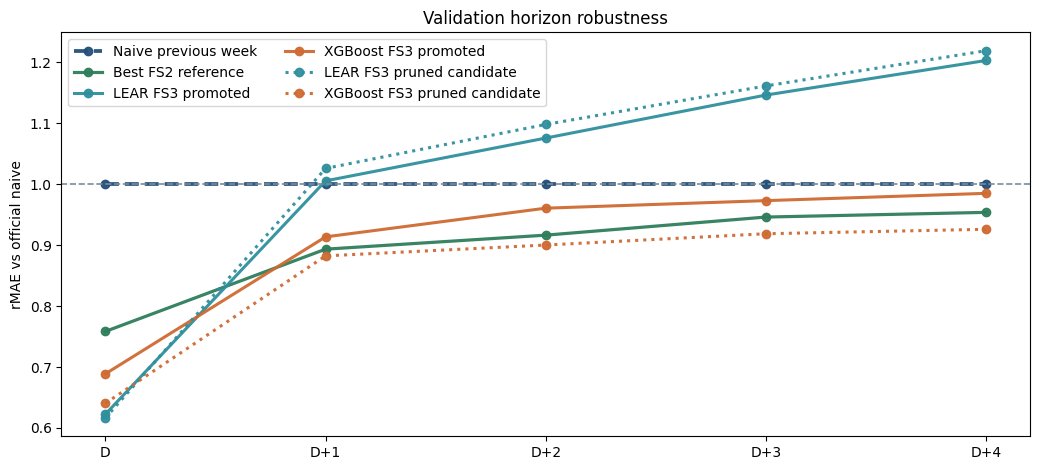

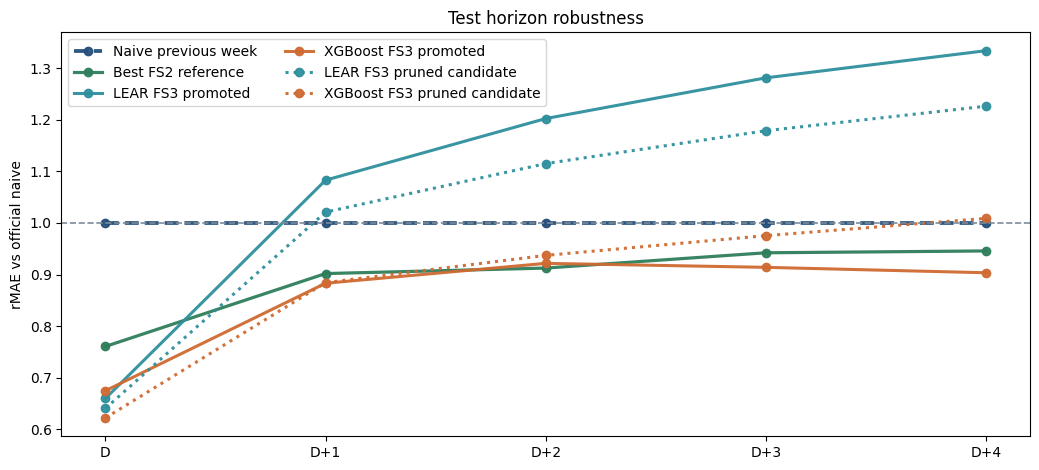

In [8]:
horizon_display = (
    horizon_metrics[
        [
            "candidate_label",
            "dataset_split",
            "lead_day_label",
            "mae",
            "rmse",
            "bias",
            "rmae",
            "median_ae",
            "p90_ae",
            "p95_ae",
            "coverage_pct",
        ]
    ]
    .sort_values(["dataset_split", "lead_day_label", "rmae", "candidate_label"])
    .reset_index(drop=True)
)
display(horizon_display)

for split_name in ("validation", "test"):
    split_frame = horizon_metrics[horizon_metrics["dataset_split"] == split_name].copy()
    if split_frame.empty:
        continue
    fig, ax = plt.subplots(figsize=(10.5, 4.8))
    for candidate_key in candidate_order:
        part = split_frame[split_frame["candidate_key"] == candidate_key].copy()
        if part.empty:
            continue
        style = candidate_style_map[candidate_key]
        part = part.sort_values("lead_day")
        ax.plot(
            part["lead_day"],
            part["rmae"],
            marker="o",
            linewidth=style["linewidth"],
            linestyle=style["linestyle"],
            color=style["color"],
            alpha=style["alpha"],
            label=style["label"],
        )
    ax.axhline(1.0, color="#7d8b99", linestyle="--", linewidth=1.2)
    ax.set_xticks(sorted(split_frame["lead_day"].astype(int).unique().tolist()))
    tick_frame = split_frame[["lead_day", "lead_day_label"]].drop_duplicates().sort_values("lead_day")
    ax.set_xticklabels(tick_frame["lead_day_label"].astype(str).tolist())
    ax.set_title(f"{split_name.capitalize()} horizon robustness")
    ax.set_ylabel("rMAE vs official naive")
    ax.legend(loc="best", ncol=2)
    fig.tight_layout()
    plt.show()


## Daily level retention


In [9]:
display(
    daily_level_summary[
        [
            "candidate_label",
            "dataset_split",
            "lead_day_label",
            "mean_daily_level_mae",
            "mean_daily_level_bias",
            "mean_abs_daily_level_bias",
            "mean_daily_volatility_error",
            "mean_abs_daily_volatility_error",
            "mean_daily_range_error",
            "mean_abs_daily_range_error",
            "valid_days",
        ]
    ]
    .sort_values(["dataset_split", "lead_day_label", "mean_daily_level_mae", "candidate_label"])
    .reset_index(drop=True)
)


,candidate_label,dataset_split,lead_day_label,mean_daily_level_mae,mean_daily_level_bias,mean_abs_daily_level_bias,mean_daily_volatility_error,mean_abs_daily_volatility_error,mean_daily_range_error,mean_abs_daily_range_error,valid_days
0,XGBoost FS3 pruned candidate,test,D,14.315863,0.749517,14.315863,-6.471983,11.789193,-23.829855,43.392857,361
1,XGBoost FS3 promoted,test,D,15.043814,1.827698,15.043814,-7.721353,13.300480,-27.740539,47.688358,361
2,LEAR FS3 pruned candidate,test,D,15.765094,0.401103,15.765094,-3.844623,9.859274,-17.780936,37.474389,361
3,LEAR FS3 promoted,test,D,15.959554,0.009145,15.959554,-2.808909,10.028592,-13.683112,38.712525,361
4,Best FS2 reference,test,D,18.115076,2.359985,18.115076,-9.278041,15.088693,-33.501123,53.412781,361
5,Naive previous week,test,D,26.750525,-0.440130,26.750525,0.069738,16.395576,0.190111,60.976593,361
6,XGBoost FS3 promoted,test,D+1,21.724787,5.194845,21.724787,-10.913331,18.078030,-37.397405,62.978101,361
7,Best FS2 reference,test,D+1,22.661247,4.964313,22.661247,-13.354075,18.806165,-45.348604,65.958513,361
8,XGBoost FS3 pruned candidate,test,D+1,22.767397,1.476372,22.767397,-7.960535,16.157620,-27.597017,57.461401,361
9,Naive previous week,test,D+1,26.784936,-0.582447,26.784936,0.169718,16.369306,0.381413,60.861247,361


## Intraday shape retention


In [10]:
display(
    daily_shape_summary[
        [
            "candidate_label",
            "dataset_split",
            "lead_day_label",
            "mean_pearson_corr",
            "mean_spearman_corr",
            "mean_demeaned_shape_mae",
            "mean_peak_hour_timing_error",
            "mean_trough_hour_timing_error",
            "valid_pearson_days",
            "valid_spearman_days",
            "flat_actual_days",
        ]
    ]
    .sort_values(["dataset_split", "lead_day_label", "mean_demeaned_shape_mae", "candidate_label"])
    .reset_index(drop=True)
)


,candidate_label,dataset_split,lead_day_label,mean_pearson_corr,mean_spearman_corr,mean_demeaned_shape_mae,mean_peak_hour_timing_error,mean_trough_hour_timing_error,valid_pearson_days,valid_spearman_days,flat_actual_days
0,LEAR FS3 promoted,test,D,0.863298,0.856091,15.917732,2.250000,2.747222,360,360,0
1,LEAR FS3 pruned candidate,test,D,0.854251,0.846063,15.933003,2.344444,2.677778,360,360,0
2,XGBoost FS3 pruned candidate,test,D,0.833665,0.825646,16.988042,2.486111,2.758333,360,360,0
3,XGBoost FS3 promoted,test,D,0.766736,0.760371,19.363818,2.966667,3.227778,360,360,0
4,Best FS2 reference,test,D,0.729810,0.732418,21.474995,3.240997,3.648199,361,361,0
5,Naive previous week,test,D,0.768218,0.786524,23.040651,3.210526,3.592798,361,361,0
6,LEAR FS3 pruned candidate,test,D+1,0.795850,0.797278,19.941748,3.249307,3.293629,361,361,0
7,LEAR FS3 promoted,test,D+1,0.803920,0.799624,20.068839,3.055402,3.354571,361,361,0
8,XGBoost FS3 pruned candidate,test,D+1,0.782227,0.780715,21.212631,3.044321,3.825485,361,361,0
9,XGBoost FS3 promoted,test,D+1,0.701149,0.712411,22.923284,3.362881,3.786704,361,361,0


## Expensive and cheap hour identification


In [11]:
display(
    topk_summary[
        [
            "candidate_label",
            "dataset_split",
            "lead_day_label",
            "mean_top3_expensive_recall",
            "mean_top3_cheap_recall",
            "valid_top3_expensive_days",
            "valid_top3_cheap_days",
        ]
    ]
    .sort_values(["dataset_split", "lead_day_label", "candidate_label"])
    .reset_index(drop=True)
)


,candidate_label,dataset_split,lead_day_label,mean_top3_expensive_recall,mean_top3_cheap_recall,valid_top3_expensive_days,valid_top3_cheap_days
0,Best FS2 reference,test,D,0.575254,0.511542,361,361
1,LEAR FS3 promoted,test,D,0.697307,0.665738,359,359
2,LEAR FS3 pruned candidate,test,D,0.689879,0.656453,359,359
3,Naive previous week,test,D,0.618652,0.603878,361,361
4,XGBoost FS3 promoted,test,D,0.573816,0.554318,359,359
5,XGBoost FS3 pruned candidate,test,D,0.667593,0.614815,360,360
6,Best FS2 reference,test,D+1,0.530009,0.502308,361,361
7,LEAR FS3 promoted,test,D+1,0.622345,0.635272,361,361
8,LEAR FS3 pruned candidate,test,D+1,0.613112,0.616805,361,361
9,Naive previous week,test,D+1,0.620499,0.606648,361,361


## Tail and stress behaviour

High-volatility days are defined here as local delivery days in the top `10%` of actual daily range within the evaluated split, because no stricter repo-level daily rule existed to reuse.


In [12]:
display(
    tail_metrics[
        [
            "candidate_label",
            "dataset_split",
            "top10_mae",
            "top10_bias",
            "bottom10_mae",
            "bottom10_bias",
            "negative_mae",
            "negative_bias",
            "p90_ae",
            "p95_ae",
            "high_volatility_day_mae",
            "high_volatility_day_bias",
        ]
    ]
    .sort_values(["dataset_split", "top10_mae", "candidate_label"])
    .reset_index(drop=True)
)


,candidate_label,dataset_split,top10_mae,top10_bias,bottom10_mae,bottom10_bias,negative_mae,negative_bias,p90_ae,p95_ae,high_volatility_day_mae,high_volatility_day_bias
0,XGBoost FS3 pruned candidate,test,55.930188,-34.480601,46.386456,40.632060,45.946470,38.375445,66.187805,85.811599,46.017057,-25.647822
1,XGBoost FS3 promoted,test,58.523484,-47.254538,51.413469,47.538714,49.435139,44.076382,66.334498,89.336662,47.201866,-19.994277
2,Naive previous week,test,59.599520,-41.734554,42.488956,31.949933,42.234232,29.007678,78.108000,96.110000,48.629483,-24.023147
3,LEAR FS3 pruned candidate,test,60.715760,-32.471472,44.552377,37.034142,42.604367,32.485502,75.846221,98.992951,49.946409,-22.897372
4,Best FS2 reference,test,64.343866,-53.697321,59.328114,58.209294,59.265194,57.697000,70.446306,93.331576,50.680940,-19.223485
5,LEAR FS3 promoted,test,67.007725,-41.138613,39.701804,28.428411,37.411205,22.544238,79.350038,106.852031,49.275186,-23.353184
6,Naive previous week,validation,31.854603,-20.533301,45.597551,35.919235,47.153808,35.043873,66.150000,80.288000,34.325783,4.844137
7,XGBoost FS3 pruned candidate,validation,34.168693,-30.775427,46.232033,42.239688,48.086567,43.227683,53.611487,67.202564,30.271661,6.601240
8,XGBoost FS3 promoted,validation,34.696457,-27.351785,55.430529,54.525901,57.141867,56.032470,60.255711,75.855762,33.405726,14.393900
9,LEAR FS3 promoted,validation,34.752163,-22.793874,39.214024,31.184847,40.318165,30.889793,60.027814,75.854569,30.427428,1.670712


## Distinctive objective week evaluation

The frozen `case_week_selection` artifact is reused directly. The main plots below use stitched `D-only` operational forecasts so that each target hour appears exactly once.


In [13]:
display(selected_core_weeks)

if not selected_appendix_weeks.empty:
    display(Markdown("### Secondary appendix-style week categories"))
    display(selected_appendix_weeks)
else:
    print("No additional appendix-style week categories were available in the frozen artifact.")


,iso_year,iso_week,iso_week_id,week_start_local_date,week_end_local_date,week_midpoint_local_date,season,expected_hours,observed_hours,observed_coverage_pct,...,weekly_max_price,weekly_range,negative_hours_count,negative_hours_share,mean_abs_hourly_change,p95_abs_hourly_change,very_high_price_hours_count,selection_score,candidate_rank,category
0,2024,50,2024-W50,2024-12-09,2024-12-15,2024-12-12,winter,168,168,100.000000,...,872.96,870.67,0,0.000000,24.074012,105.260,34,136.827714,1,high_volatility
1,2025,34,2025-W34,2025-08-18,2025-08-24,2025-08-21,summer,168,168,100.000000,...,190.15,197.60,6,0.035714,11.537186,35.215,0,1.677153,1,typical_summer
2,2025,8,2025-W08,2025-02-17,2025-02-23,2025-02-20,winter,168,167,99.404762,...,262.37,231.58,0,0.000000,13.008242,42.850,5,0.942163,1,typical_winter


### Secondary appendix-style week categories

,iso_year,iso_week,iso_week_id,week_start_local_date,week_end_local_date,week_midpoint_local_date,season,expected_hours,observed_hours,observed_coverage_pct,...,weekly_max_price,weekly_range,negative_hours_count,negative_hours_share,mean_abs_hourly_change,p95_abs_hourly_change,very_high_price_hours_count,selection_score,candidate_rank,category
0,2025,7,2025-W07,2025-02-10,2025-02-16,2025-02-13,winter,168,168,100.000000,...,275.77,212.77,0,0.000000,11.567126,32.517,10,143.738869,2,high_price
1,2025,38,2025-W38,2025-09-15,2025-09-21,2025-09-18,shoulder,168,164,97.619048,...,373.71,384.36,28,0.170732,16.566226,55.504,2,53.244573,1,low_price
2,2025,20,2025-W20,2025-05-12,2025-05-18,2025-05-15,shoulder,168,168,100.000000,...,212.92,269.88,43,0.255952,18.182156,64.505,1,0.255952,1,negative_price


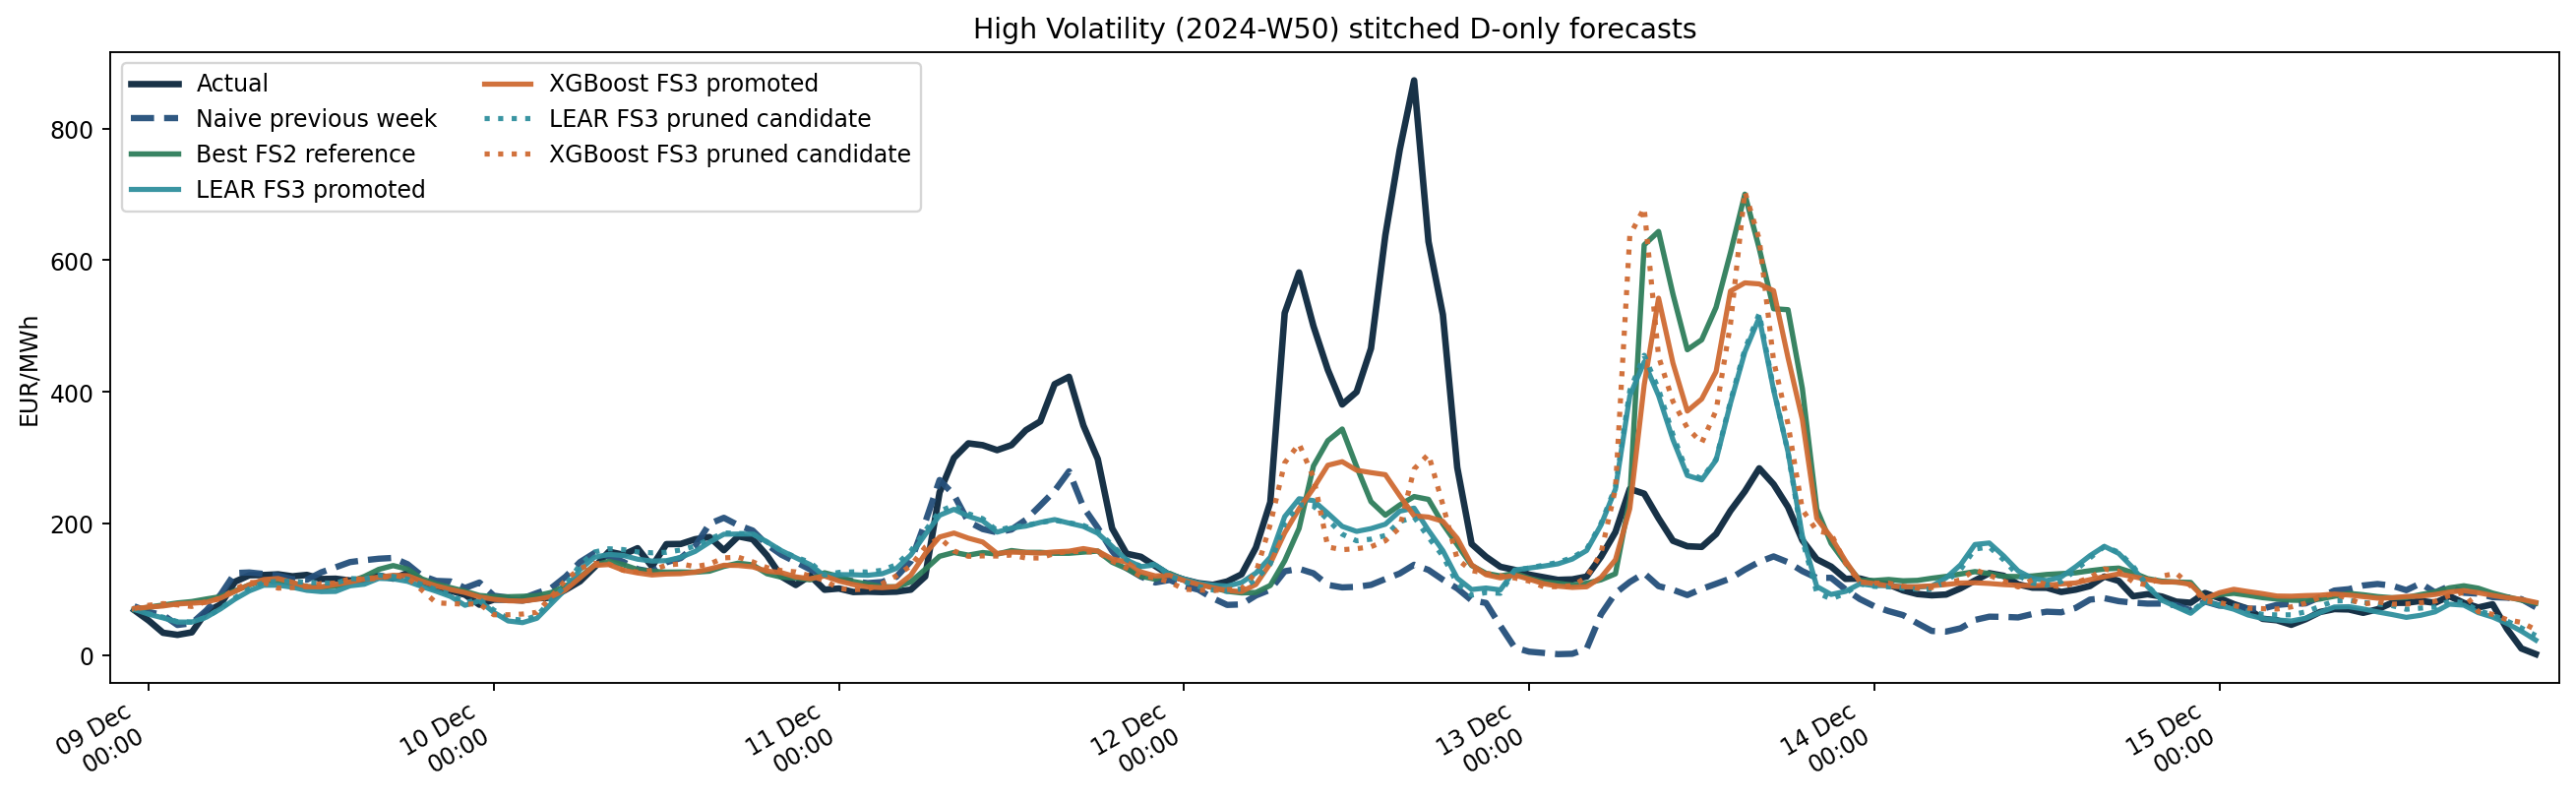

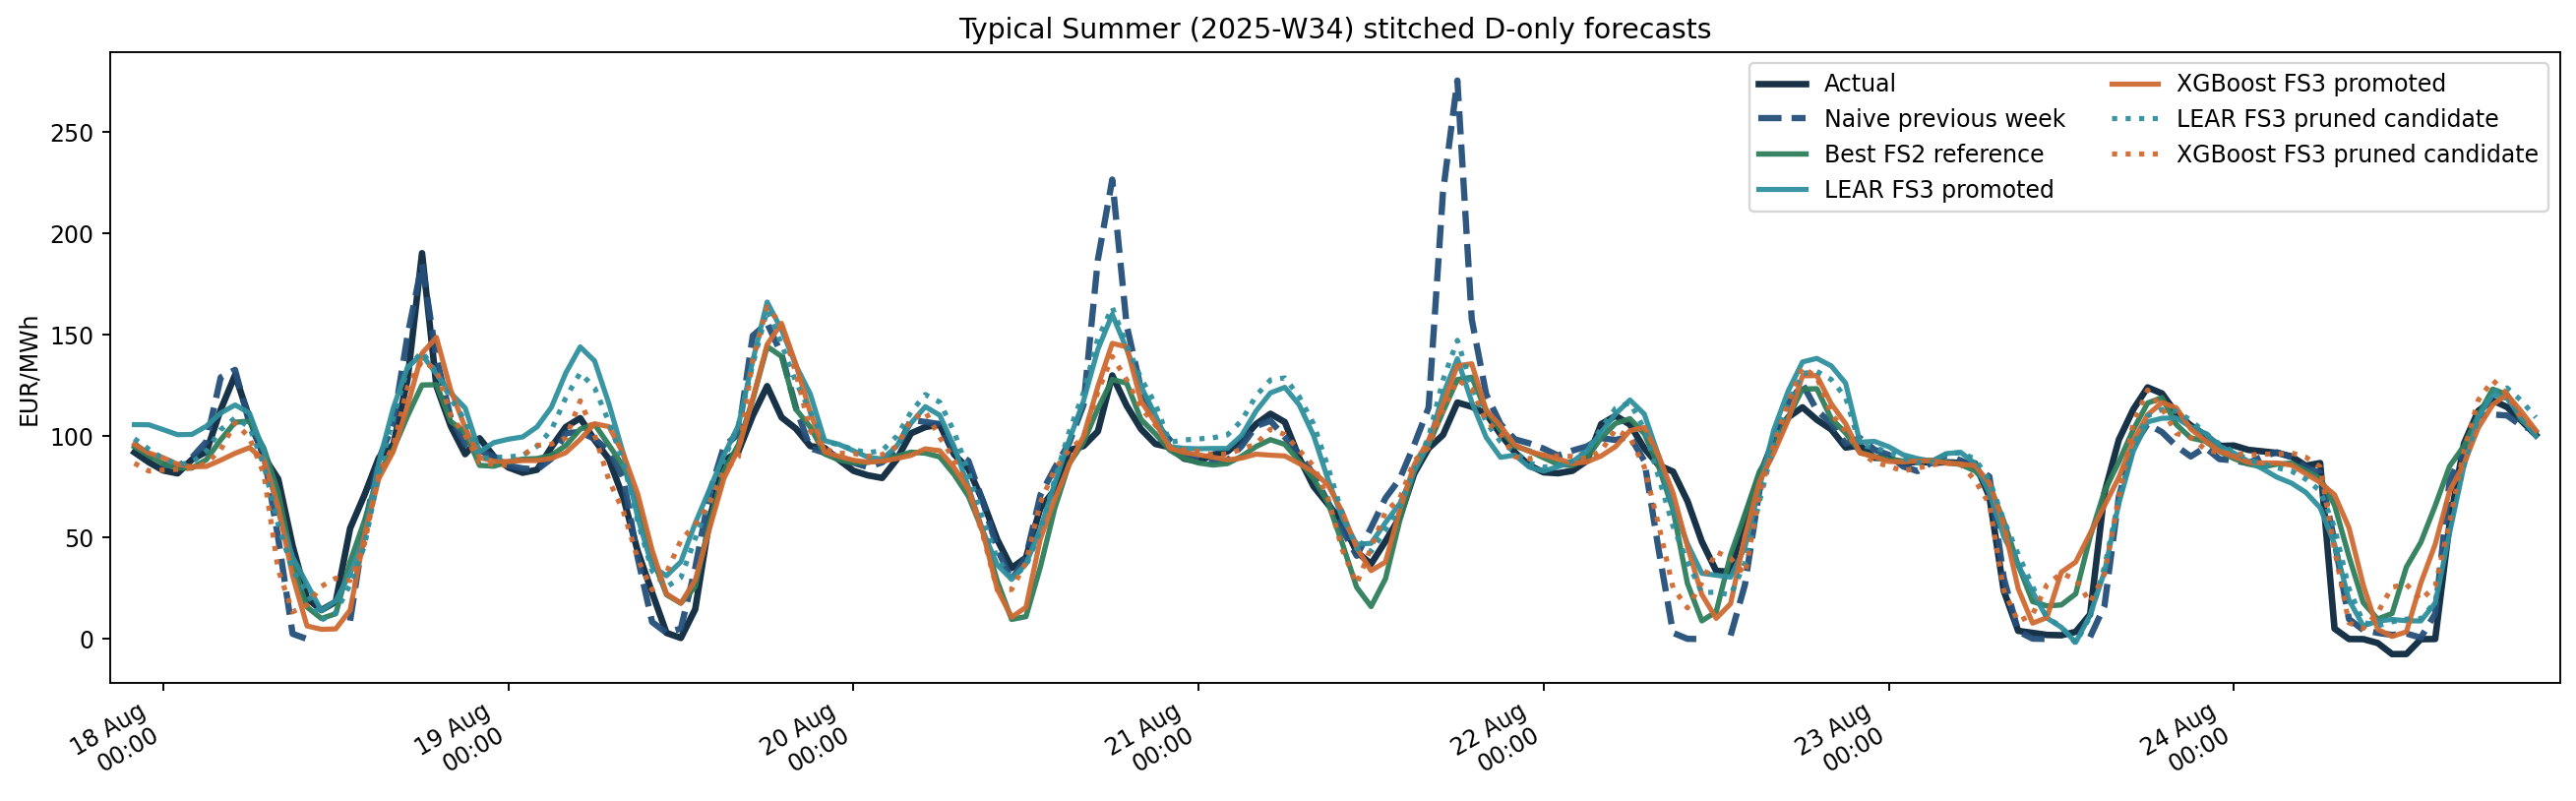

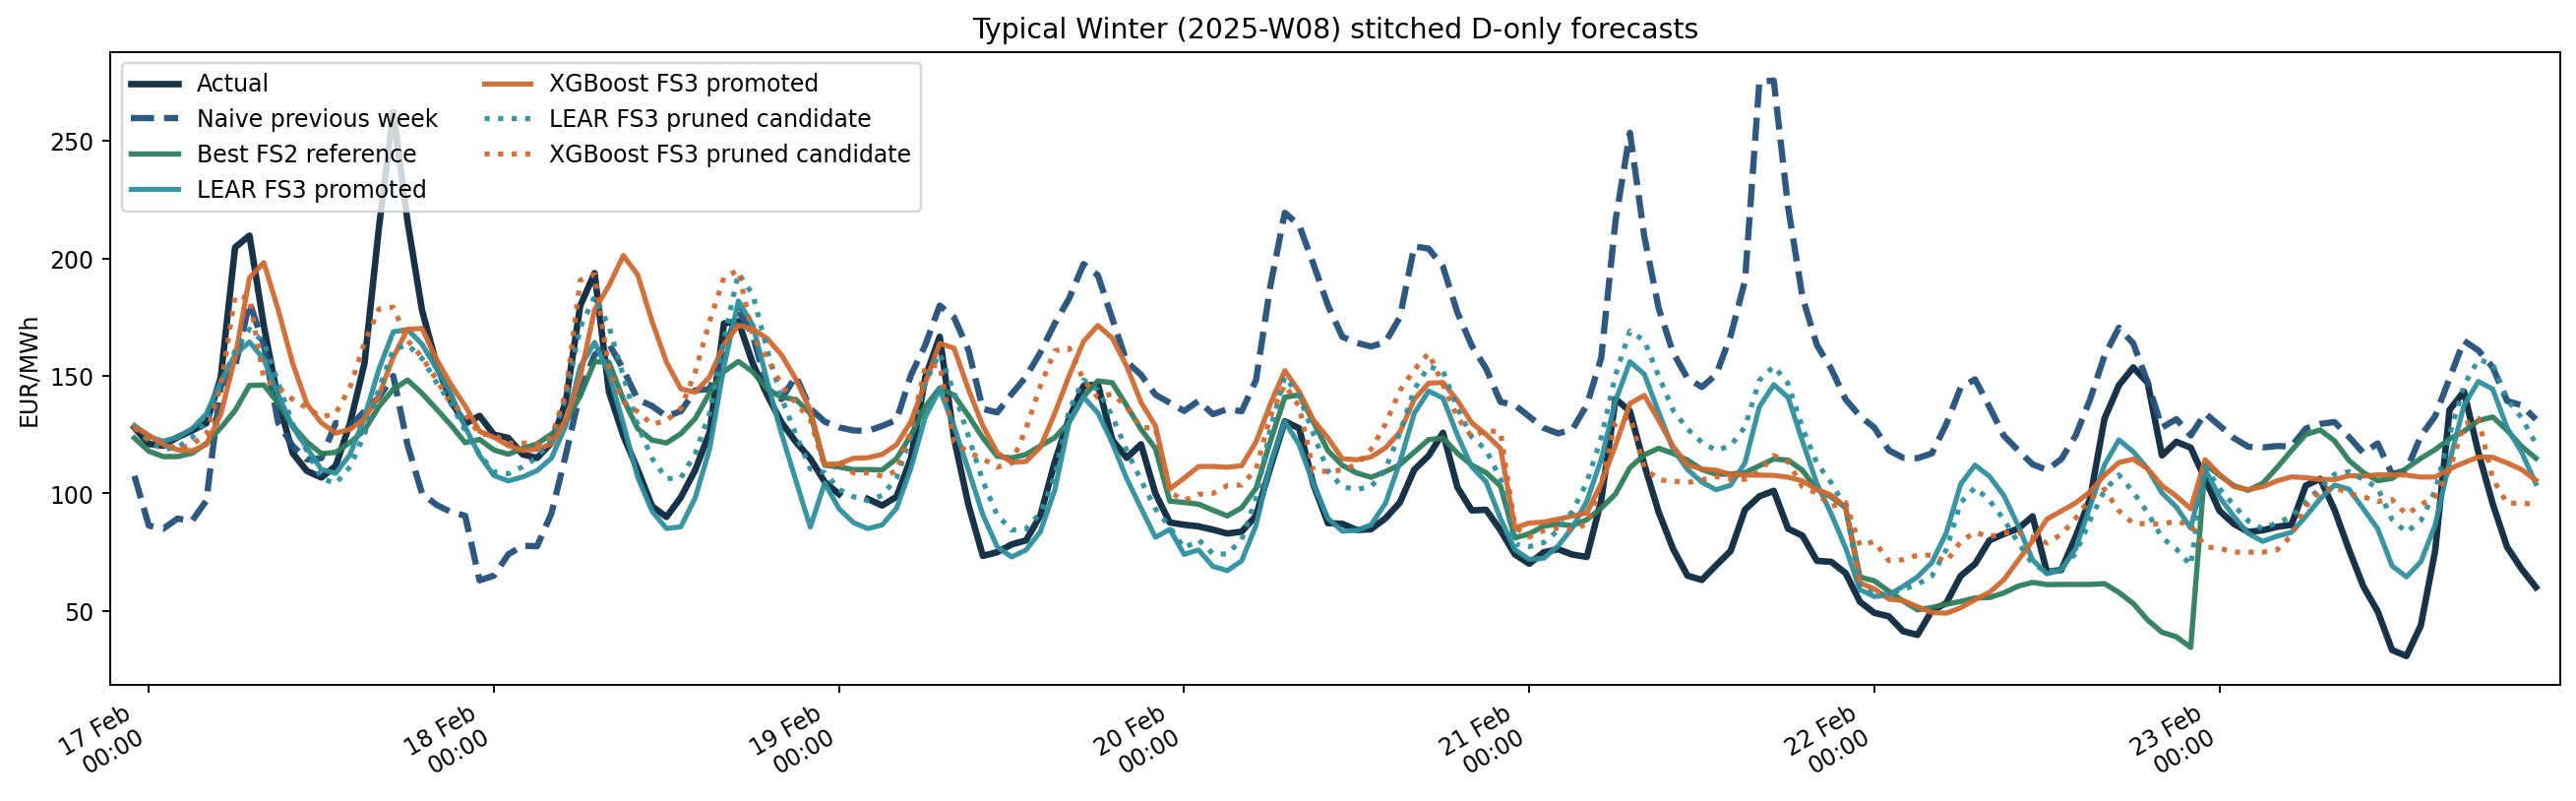

,Week type,ISO week,Candidate label,MAE,rMAE,Bias,Shape summary,Top-3 expensive recall,Top-3 cheap recall
0,High Volatility,2024-W50,LEAR FS3 promoted,61.408215,0.845698,-23.187641,"ρ=0.88, ρs=0.81, de-meaned MAE=51.52",0.428571,0.666667
1,High Volatility,2024-W50,LEAR FS3 pruned candidate,62.325594,0.858331,-21.893179,"ρ=0.88, ρs=0.79, de-meaned MAE=52.03",0.333333,0.571429
2,High Volatility,2024-W50,XGBoost FS3 promoted,67.982428,0.936236,-15.326039,"ρ=0.70, ρs=0.65, de-meaned MAE=61.02",0.190476,0.523810
3,High Volatility,2024-W50,XGBoost FS3 pruned candidate,69.784360,0.961052,-17.457274,"ρ=0.76, ρs=0.74, de-meaned MAE=60.29",0.285714,0.619048
4,High Volatility,2024-W50,Naive previous week,72.612500,1.000000,-54.902857,"ρ=0.67, ρs=0.64, de-meaned MAE=48.05",0.380952,0.523810
5,High Volatility,2024-W50,Best FS2 reference,76.441586,1.052733,-8.347508,"ρ=0.74, ρs=0.73, de-meaned MAE=68.22",0.190476,0.571429
6,Typical Summer,2025-W34,Best FS2 reference,10.496340,0.807720,0.935167,"ρ=0.94, ρs=0.94, de-meaned MAE=10.71",0.761905,0.904762
7,Typical Summer,2025-W34,XGBoost FS3 pruned candidate,11.088420,0.853282,0.916416,"ρ=0.91, ρs=0.93, de-meaned MAE=11.04",0.809524,0.523810
8,Typical Summer,2025-W34,XGBoost FS3 promoted,12.082897,0.929809,1.568362,"ρ=0.93, ρs=0.90, de-meaned MAE=11.85",0.571429,0.952381
9,Typical Summer,2025-W34,LEAR FS3 pruned candidate,12.596926,0.969365,5.678651,"ρ=0.94, ρs=0.93, de-meaned MAE=10.34",0.666667,0.857143


In [14]:
week_plot_paths = []
plot_output_dir = report_output_dir / "core_week_plots"
plot_output_dir.mkdir(parents=True, exist_ok=True)

for week_row in selected_core_weeks.to_dict(orient="records"):
    week_start = pd.Timestamp(week_row["week_start_local_date"]).date()
    week_end = pd.Timestamp(week_row["week_end_local_date"]).date()
    week_frame = stitched_test_predictions[
        (stitched_test_predictions["target_local_date"] >= week_start)
        & (stitched_test_predictions["target_local_date"] <= week_end)
        & (stitched_test_predictions["candidate_key"].isin(week_plot_candidate_keys))
    ].copy()
    if week_frame.empty:
        continue

    actual = (
        week_frame[["target_timestamp_utc", "target_timestamp_local", "y_true"]]
        .drop_duplicates(subset=["target_timestamp_utc"])
        .sort_values("target_timestamp_utc")
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=(15.5, 4.9))
    ax.plot(actual["target_timestamp_local"], actual["y_true"], color="#183247", linewidth=2.8, label="Actual")
    for candidate_key in week_plot_candidate_keys:
        candidate_part = week_frame[week_frame["candidate_key"] == candidate_key].copy()
        if candidate_part.empty:
            continue
        candidate_part = candidate_part.sort_values("target_timestamp_utc")
        style = candidate_style_map[candidate_key]
        ax.plot(
            candidate_part["target_timestamp_local"],
            candidate_part["y_pred"],
            color=style["color"],
            linestyle=style["linestyle"],
            linewidth=style["linewidth"],
            alpha=style["alpha"],
            label=style["label"],
        )
    ax.set_title(
        f"{week_row['category'].replace('_', ' ').title()} ({week_row['iso_week_id']}) stitched D-only forecasts"
    )
    ax.set_ylabel("EUR/MWh")
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
    ax.margins(x=0.01)
    ax.legend(loc="best", ncol=2)
    fig.autofmt_xdate()
    fig.tight_layout()
    output_path = plot_output_dir / f"{week_row['category']}_stitched_d_only.png"
    fig.savefig(output_path, dpi=170, bbox_inches="tight")
    plt.close(fig)
    week_plot_paths.append(output_path)

for path in week_plot_paths:
    display(Image(filename=str(path)))

week_metric_display = (
    week_metric_summary.assign(
        week_type=lambda frame: frame["category"].astype(str).str.replace("_", " ").str.title(),
        shape_summary=lambda frame: frame.apply(
            lambda row: (
                "-"
                if pd.isna(row["mean_pearson_corr"])
                else f"ρ={float(row['mean_pearson_corr']):.2f}, ρs={float(row['mean_spearman_corr']):.2f}, de-meaned MAE={float(row['mean_demeaned_shape_mae']):.2f}"
            ),
            axis=1,
        ),
    )[
        [
            "week_type",
            "iso_week_id",
            "candidate_label",
            "mae",
            "rmae",
            "bias",
            "shape_summary",
            "mean_top3_expensive_recall",
            "mean_top3_cheap_recall",
        ]
    ]
    .rename(
        columns={
            "week_type": "Week type",
            "iso_week_id": "ISO week",
            "candidate_label": "Candidate label",
            "mae": "MAE",
            "rmae": "rMAE",
            "bias": "Bias",
            "shape_summary": "Shape summary",
            "mean_top3_expensive_recall": "Top-3 expensive recall",
            "mean_top3_cheap_recall": "Top-3 cheap recall",
        }
    )
    .sort_values(["Week type", "MAE", "Candidate label"])
    .reset_index(drop=True)
)
display(week_metric_display)


## Scenario and probabilistic placeholder

Scenario/probabilistic metrics are unavailable from the current deterministic benchmark artifacts. Later scenario generation should be evaluated separately for empirical coverage, interval width, and tail representation.


## Runtime and implementability summary


In [15]:
display(
    candidate_runtime[
        [
            "candidate_label",
            "dataset_split",
            "fit_time_mean_sec",
            "fit_time_median_sec",
            "fit_time_max_sec",
            "fit_time_warning_count",
            "predict_time_mean_sec",
            "predict_time_median_sec",
        ]
    ]
    .sort_values(["dataset_split", "fit_time_mean_sec", "candidate_label"])
    .reset_index(drop=True)
)

if candidate_settings.empty:
    print("No model_settings_summary rows were available.")
else:
    settings_display = (
        candidate_settings[
            [
                "candidate_label",
                "settings_source",
                "settings_json",
            ]
        ]
        .assign(
            settings_json=lambda frame: frame["settings_json"].astype(str).str.slice(0, 200)
            + frame["settings_json"].astype(str).map(lambda value: "..." if len(value) > 200 else "")
        )
        .rename(
            columns={
                "candidate_label": "Candidate label",
                "settings_source": "Settings source",
                "settings_json": "Settings preview",
            }
        )
    )
    display(settings_display)

display(
    selection_summary[
        [
            "candidate_label",
            "runtime_note",
            "implementability_note",
            "recommended_yes_no",
        ]
    ]
    .rename(
        columns={
            "candidate_label": "Candidate label",
            "runtime_note": "Runtime note",
            "implementability_note": "Implementability note",
            "recommended_yes_no": "Recommended",
        }
    )
)

display(timing_summary)


,candidate_label,dataset_split,fit_time_mean_sec,fit_time_median_sec,fit_time_max_sec,fit_time_warning_count,predict_time_mean_sec,predict_time_median_sec
0,Naive previous week,test,0.000980,0.000844,0.004149,0,0.002204,0.001945
1,LEAR FS3 pruned candidate,test,0.148836,0.138369,0.269390,0,1.440024,1.391985
2,Best FS2 reference,test,0.162558,0.160952,0.262854,0,1.242289,1.238261
3,LEAR FS3 promoted,test,0.205188,0.197273,0.343743,0,1.497082,1.448889
4,XGBoost FS3 pruned candidate,test,0.344736,0.342446,0.532564,0,1.665728,1.647640
5,XGBoost FS3 promoted,test,1.761966,2.116475,3.331296,0,5.282668,6.433172
6,Naive previous week,validation,0.001159,0.000814,0.092179,0,0.002084,0.001907
7,LEAR FS3 pruned candidate,validation,0.115832,0.113450,0.428083,0,1.180885,1.177834
8,Best FS2 reference,validation,0.155480,0.156484,0.298749,0,1.077233,1.125090
9,LEAR FS3 promoted,validation,0.185947,0.177291,0.386672,0,1.453134,1.423071


,Candidate label,Settings source,Settings preview
0,Best FS2 reference,runtime_info_json_backfill,"{""colsample_bytree"": 0.9, ""fs3_experiment"": nu..."
1,LEAR FS3 promoted,model.settings,"{""branch_mode"": ""d_only_vs_guidance"", ""d_only_..."
2,LEAR FS3 pruned candidate,model.settings,"{""branch_mode"": ""d_only_vs_guidance"", ""d_only_..."
3,Naive previous week,runtime_info_json_backfill,"{""fit_failed"": false, ""strategy"": ""local_previ..."
4,XGBoost FS3 promoted,model.settings,"{""branch_mode"": ""d_only_vs_guidance"", ""d_only_..."
5,XGBoost FS3 pruned candidate,model.settings,"{""branch_mode"": ""d_only_vs_guidance"", ""d_only_..."


,Candidate label,Runtime note,Implementability note,Recommended
0,XGBoost FS3 pruned candidate,"fit 0.35s, predict 1.64s",Reduced FS3 tree candidate. Still less interpr...,True
1,Best FS2 reference,"fit 0.16s, predict 1.08s","Operationally practical nonlinear model, but l...",False
2,LEAR FS3 promoted,"fit 0.19s, predict 1.45s",Full FS3 causal stack on a linear base. More e...,False
3,LEAR FS3 pruned candidate,"fit 0.12s, predict 1.18s",Reduced FS3 linear candidate. Keeps some FS3 b...,False
4,Naive previous week,"fit 0.00s, predict 0.00s",Minimal implementation cost and maximum transp...,False
5,XGBoost FS3 promoted,"fit 1.03s, predict 2.89s",Highest complexity among current candidates be...,False


,step,seconds
0,compute_topk_hour_metrics_top3_only,183.634561
1,compute_daily_shape_metrics,183.155679
2,compute_daily_level_metrics,37.835460
3,load_candidate_predictions,16.324987
4,compute_dm_vs_naive,2.660305
5,compute_horizon_metrics,2.509264
6,compute_dm_vs_best_fs2,2.465687
7,build_week_metric_summary,2.280979
8,compute_classical_metrics,1.435221
9,compute_tail_metrics,1.325395


## Final recommendation table


In [16]:
selection_summary_display = selection_summary.rename(
    columns={
        "candidate_context": "Model context",
        "candidate_label": "Candidate label",
        "classical_metrics_summary": "Classical metrics summary",
        "horizon_robustness_summary": "Horizon robustness summary",
        "level_retention_summary": "Level retention summary",
        "shape_retention_summary": "Shape retention summary",
        "expensive_hour_recall_summary": "Expensive-hour recall",
        "cheap_hour_recall_summary": "Cheap-hour recall",
        "tail_stress_note": "Tail/stress note",
        "runtime_note": "Runtime / fit-time note",
        "implementability_note": "Implementability note",
        "recommended_yes_no": "Recommended",
        "thesis_use_limitations": "Thesis-use limitations",
        "notes": "Notes",
    }
)
display(selection_summary_display)


,Model context,Candidate label,Classical metrics summary,Horizon robustness summary,Level retention summary,Shape retention summary,Expensive-hour recall,Cheap-hour recall,Tail/stress note,Runtime / fit-time note,Implementability note,Recommended,Thesis-use limitations,Notes
0,fs3_pruned_candidate,XGBoost FS3 pruned candidate,"val rMAE 0.854, val MAE 23.78, test rMAE 0.886",100% of validation horizons below rMAE 1.00,"mean daily level MAE 11.99, mean daily bias -0.06","Pearson 0.82, Spearman 0.80, de-meaned shape M...",Top-3 expensive recall 0.62,Top-3 cheap recall 0.54,"Top-10% MAE 34.17, high-volatility-day MAE 30....","fit 0.35s, predict 1.64s",Reduced FS3 tree candidate. Still less interpr...,True,Document deterministic-only limitations and re...,XGBoost FS3 pruned candidate improves validati...
1,fs2_reference,Best FS2 reference,"val rMAE 0.894, val MAE 24.90, test rMAE 0.893",100% of validation horizons below rMAE 1.00,"mean daily level MAE 14.40, mean daily bias +4.03","Pearson 0.72, Spearman 0.72, de-meaned shape M...",Top-3 expensive recall 0.54,Top-3 cheap recall 0.47,"Top-10% MAE 35.50, high-volatility-day MAE 35....","fit 0.16s, predict 1.08s","Operationally practical nonlinear model, but l...",False,Document deterministic-only limitations and re...,
2,fs3_promoted,LEAR FS3 promoted,"val rMAE 1.011, val MAE 28.16, test rMAE 1.113",20% of validation horizons below rMAE 1.00,"mean daily level MAE 11.99, mean daily bias -0.54","Pearson 0.87, Spearman 0.86, de-meaned shape M...",Top-3 expensive recall 0.68,Top-3 cheap recall 0.65,"Top-10% MAE 34.75, high-volatility-day MAE 30....","fit 0.19s, predict 1.45s",Full FS3 causal stack on a linear base. More e...,False,Document deterministic-only limitations and re...,
3,fs3_pruned_candidate,LEAR FS3 pruned candidate,"val rMAE 1.025, val MAE 28.54, test rMAE 1.037",20% of validation horizons below rMAE 1.00,"mean daily level MAE 11.45, mean daily bias -0.67","Pearson 0.86, Spearman 0.86, de-meaned shape M...",Top-3 expensive recall 0.69,Top-3 cheap recall 0.66,"Top-10% MAE 36.60, high-volatility-day MAE 37....","fit 0.12s, predict 1.18s",Reduced FS3 linear candidate. Keeps some FS3 b...,False,Document deterministic-only limitations and re...,
4,benchmark,Naive previous week,"val rMAE 1.000, val MAE 27.86, test rMAE 1.000",0% of validation horizons below rMAE 1.00,"mean daily level MAE 22.43, mean daily bias +0.36","Pearson 0.77, Spearman 0.78, de-meaned shape M...",Top-3 expensive recall 0.60,Top-3 cheap recall 0.57,"Top-10% MAE 31.85, high-volatility-day MAE 34....","fit 0.00s, predict 0.00s",Minimal implementation cost and maximum transp...,False,Baseline only; use only if stronger models fai...,
5,fs3_promoted,XGBoost FS3 promoted,"val rMAE 0.904, val MAE 25.20, test rMAE 0.860",100% of validation horizons below rMAE 1.00,"mean daily level MAE 12.72, mean daily bias +2.89","Pearson 0.76, Spearman 0.76, de-meaned shape M...",Top-3 expensive recall 0.53,Top-3 cheap recall 0.48,"Top-10% MAE 34.70, high-volatility-day MAE 33....","fit 1.03s, predict 2.89s",Highest complexity among current candidates be...,False,Document deterministic-only limitations and re...,


## Conclusion


In [17]:
recommended_key = recommendation.get("recommended_candidate_key")
recommended_label = recommendation.get("recommended_candidate_label")
recommended_row = selection_inputs[selection_inputs["candidate_key"] == recommended_key].copy()
recommended_row = recommended_row.iloc[0] if not recommended_row.empty else None
best_fs2_row = selection_inputs[selection_inputs["candidate_key"] == "best_fs2_reference"].copy()
best_fs2_row = best_fs2_row.iloc[0] if not best_fs2_row.empty else None
naive_row = selection_inputs[selection_inputs["candidate_key"] == "official_naive_benchmark"].copy()
naive_row = naive_row.iloc[0] if not naive_row.empty else None

if recommended_row is None:
    display(Markdown("No DA candidate could be recommended from the available benchmark-parent artifacts."))
else:
    delta_vs_fs2 = (
        float(best_fs2_row["rmae"] - recommended_row["rmae"])
        if best_fs2_row is not None and pd.notna(best_fs2_row["rmae"]) and pd.notna(recommended_row["rmae"])
        else float("nan")
    )
    delta_vs_naive = (
        float(naive_row["rmae"] - recommended_row["rmae"])
        if naive_row is not None and pd.notna(naive_row["rmae"]) and pd.notna(recommended_row["rmae"])
        else float("nan")
    )
    fs3_selected = str(recommended_key).startswith("lear_fs3") or str(recommended_key).startswith("xgboost_fs3")
    conclusion_lines = [
        "### Decision outcome",
        f"- At least one DA forecast candidate is {'sufficient' if recommendation.get('stop_da_here') else 'not yet sufficient'} for downstream thesis use under the current deterministic scope.",
        f"- Recommended DA candidate: `{recommended_label}`.",
        f"- Validation `rMAE` versus the official naive benchmark: `{float(recommended_row['rmae']):.3f}`.",
        f"- Test `rMAE` versus the official naive benchmark: `{float(recommended_row['test_rmae']):.3f}`." if pd.notna(recommended_row["test_rmae"]) else "- Test `rMAE` versus the official naive benchmark: unavailable.",
    ]
    if pd.notna(delta_vs_naive):
        conclusion_lines.append(f"- Improvement versus the official naive benchmark on validation: `{delta_vs_naive:.3f}` rMAE points.")
    if best_fs2_row is not None and pd.notna(delta_vs_fs2):
        comparison_text = "improves enough over" if fs3_selected and delta_vs_fs2 > 0 else "does not improve enough over"
        conclusion_lines.append(
            f"- Relative to the best/current FS2 reference, the selected candidate {comparison_text} FS2 by `{delta_vs_fs2:.3f}` validation rMAE points."
        )
    conclusion_lines.extend(
        [
            f"- Recommendation rationale: {recommendation.get('decision_reason')}",
            f"- DA forecasting work should {'stop here' if recommendation.get('stop_da_here') else 'continue'} before expanding the thesis scope.",
            f"- It is {'methodologically reasonable' if recommendation.get('move_to_mfrr') else 'not yet methodologically reasonable'} to move on to mFRR forecasting next.",
            "- Thesis limitations to document: deterministic-only outputs, residual tail risk, and any remaining daily level bias or week-specific failure modes shown above.",
        ]
    )
    display(Markdown("\n".join(conclusion_lines)))


### Decision outcome
- At least one DA forecast candidate is sufficient for downstream thesis use under the current deterministic scope.
- Recommended DA candidate: `XGBoost FS3 pruned candidate`.
- Validation `rMAE` versus the official naive benchmark: `0.854`.
- Test `rMAE` versus the official naive benchmark: `0.886`.
- Improvement versus the official naive benchmark on validation: `0.146` rMAE points.
- Relative to the best/current FS2 reference, the selected candidate improves enough over FS2 by `0.040` validation rMAE points.
- Recommendation rationale: XGBoost FS3 pruned candidate improves validation rMAE enough over the best FS2 reference without triggering the configured simplicity fallback.
- DA forecasting work should stop here before expanding the thesis scope.
- It is methodologically reasonable to move on to mFRR forecasting next.
- Thesis limitations to document: deterministic-only outputs, residual tail risk, and any remaining daily level bias or week-specific failure modes shown above.